In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Reading data

In [2]:
df_cases = pd.read_excel("../resources/weekly_varicella_hun.xlsx", sheet_name="weekly_cases")
df_births = pd.read_excel("../resources/births_hun.xlsx", sheet_name="births")
df_deaths = pd.read_excel("../resources/deaths_hun.xlsx", sheet_name="deaths")
df_vaccines = pd.read_excel("../resources/vaccine_coverage_hun.xlsx", sheet_name="vaccines")

## 2. Convert dates and set indices

### Varicella data

In [3]:
# "2020_1" → split year and week
df_cases[["Year", "WeekNum"]] = df_cases["Week"].str.split("_", expand=True)
df_cases["Year"] = df_cases["Year"].astype(int)
df_cases["WeekNum"] = df_cases["WeekNum"].astype(int)

# ISO week -> date (the first day of the week, Monday)
df_cases["Date"] = pd.to_datetime(df_cases["Year"].astype(str) + df_cases["WeekNum"].astype(str) + "1", format="%G%V%u")

# set date index
df_weekly_cases = df_cases.set_index("Date").sort_index()

start_of_vaccination = pd.Timestamp("2019-09-01")

detection_rate_before = 0.4
detection_rate_after = 0.4

weekly_cases = df_weekly_cases["Cases"].copy()

weekly_cases.loc[weekly_cases.index < start_of_vaccination] *= 1 / detection_rate_before
weekly_cases.loc[weekly_cases.index >= start_of_vaccination] *= 1 / detection_rate_after

# fill missing values
full_index = pd.date_range(
    start=weekly_cases.index.min(),
    end=weekly_cases.index.max(),
    freq="W-MON"
)
weekly_cases_full = weekly_cases.reindex(full_index)
weekly_cases_filled = weekly_cases_full.interpolate(method="linear")
print(weekly_cases_filled)

2000-01-03    2217.5
2000-01-10    2545.0
2000-01-17    2145.0
2000-01-24    2740.0
2000-01-31    2375.0
               ...  
2025-11-24     210.0
2025-12-01     322.5
2025-12-08     450.0
2025-12-15     390.0
2025-12-22     197.5
Freq: W-MON, Name: Cases, Length: 1356, dtype: float64


### Birth and death data; vaccination coverage

In [4]:
weekly_index = weekly_cases_filled.index

# Yearly data in dictionary format
births_yearly = dict(zip(df_births["Year"], df_births["Cases"]))
deaths_yearly = dict(zip(df_deaths["Year"], df_deaths["Cases"]))
vaccines_yearly = dict(zip(df_vaccines["Year"], df_vaccines["Cases"]))

# Empty series for the weekly data
weekly_births = pd.Series(index=weekly_index, dtype=float)
weekly_deaths = pd.Series(index=weekly_index, dtype=float)
weekly_vaccines = pd.Series(index=weekly_index, dtype=float)

# Filling
for date in weekly_index:
    year = date.year
    weekly_births.loc[date] = births_yearly[year] / 52
    weekly_deaths.loc[date] = deaths_yearly[year] / 52
    weekly_vaccines.loc[date] = vaccines_yearly[year] / 52

## 3. Calculating the number of susceptibles


In [5]:
i = weekly_cases_filled.values
v = weekly_vaccines.values
T = len(i)

S_scen0 = np.zeros(T)
N = np.zeros(T)

# Values are from number_of_susceptibles_hun.xlsx
N0 = 10200198
S_scen0[0] = 1222086
N[0] = N0

for t in range(1, T):
    # Update the number of susceptibles
    S_scen0[t] = S_scen0[t - 1] + weekly_births.iloc[t - 1] - i[t - 1] - v[t - 1] * 0.8 - weekly_deaths.iloc[t - 1] * (S_scen0[t - 1] / N[t - 1])

    # Update the population
    N[t] = N[t-1] + weekly_births.iloc[t-1] - weekly_deaths.iloc[t-1]

## 4. Estimate R_t using renewal equation model

In [6]:
L = 2 # length of latent period in weeks
D = 1 # length of infectious period in weeks

sigma = 1/2   # length of latent period is 2 weeks
gamma = 1   # length of infectious period is 1 week

max_tau = 3
tau = np.arange(1, max_tau+1)
g = (sigma * gamma / (gamma - sigma)) * (np.exp(-sigma * tau) - np.exp(-gamma * tau))
g = g / g.sum()          # normalizing

remainders_t = np.zeros(T)
R_t = np.zeros(T)

for t in range(max_tau, T):
    mu_t = weekly_deaths.iloc[t] / N[t]
    year = weekly_cases_filled.index[t].year

    # infectiousness kernel considering demography
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))

    # weighted sum of past incidences
    denom = np.sum(i[t - np.arange(1, max_tau+1)] * kernel)

    if denom > 0 and S_scen0[t] > 0:
        s_t = S_scen0[t] / N[t]
        remainders_t[t] = i[t] / (s_t * denom)
        #R_t[t] = i[t] / (s_t * denom)
        #R_t[t] = i[t] / (denom)
    else:
        remainders_t[t] = np.nan

## 5. Plot results for R_t

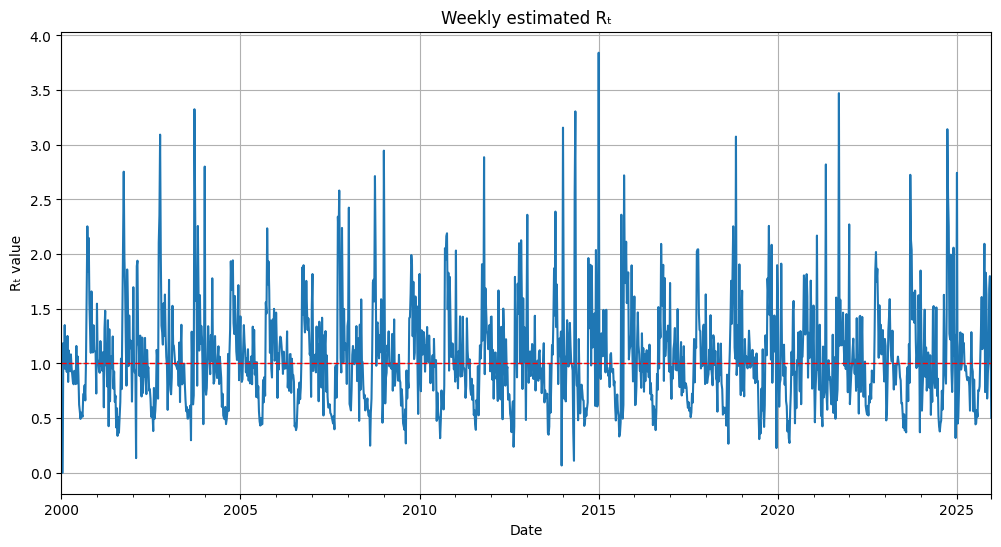

In [7]:
for t in range(max_tau, T):
    s_t = S_scen0[t] / N[t]
    R_t[t] = remainders_t[t] * s_t

weekly_remainders_t = pd.Series(remainders_t, index=weekly_cases_filled.index)
weekly_Rt = pd.Series(R_t, index=weekly_cases_filled.index)

plt.figure(figsize=(12, 6))
weekly_Rt.plot()

plt.axhline(1.0, color='red', linestyle='--', linewidth=1)  # R=1 as reference
plt.title("Weekly estimated Rₜ")
plt.ylabel("Rₜ value")
plt.xlabel("Date")
plt.grid(True)

plt.show()

## 6. Plot results for the number of incidences

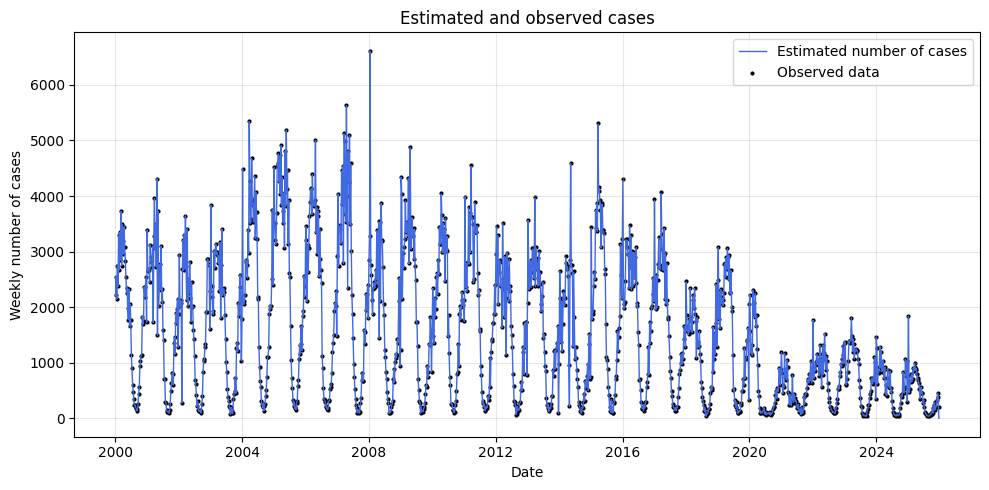

In [8]:
i_model = np.zeros(T)
for t in range(0, max_tau):
    i_model[t] = i[t]

for t in range(max_tau, T-1):
    s_t = S_scen0[t] / N[t]
    #i_model[t] = s_t * R_t[t] * np.sum(i_model[t - np.arange(1, max_tau+1)] * g)
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    i_model[t] = R_t[t] * np.sum(i_model[t - np.arange(1, max_tau+1)] * kernel)

weekly_i_model = pd.Series(i_model, index=weekly_cases_filled.index)

plt.figure(figsize=(10, 5))

plt.plot(weekly_i_model.index, weekly_i_model.values,
         label="Estimated number of cases", color="royalblue", linewidth=1)

plt.scatter(
    weekly_cases_filled.index,
    weekly_cases_filled.values,
    color="black",
    s=4,
    label="Observed data"
)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Incidences without vaccination

In [19]:
S_scen1 = np.zeros(T)

# Values are from number_of_susceptibles_hun.xlsx
S_scen1[0] = 1222086

for t in range(1, T):
    # Update the number of susceptibles
    S_scen1[t] = S_scen1[t - 1] + weekly_births.iloc[t - 1] - i[t - 1] - v[t - 1] * 0 - weekly_deaths.iloc[t - 1] * (S_scen1[t - 1] / N[t - 1])

In [20]:
R_t_scen1 = np.zeros(T)

for t in range(max_tau, T):
    s_t = S_scen1[t] / N[t]
    R_t_scen1[t] = remainders_t[t] * s_t

In [22]:
i_scen1 = np.zeros(T)
for t in range(0, max_tau):
    i_scen1[t] = i[t]

for t in range(max_tau, T-1):
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    i_scen1[t] = R_t_scen1[t] * np.sum(i_scen1[t - np.arange(1, max_tau+1)] * kernel)

weekly_i_scen1 = pd.Series(i_scen1, index=weekly_cases_filled.index)

plt.figure(figsize=(10, 5))

plt.plot(weekly_i_scen1.index, weekly_i_scen1.values,
         label="Estimated number of cases", color="royalblue", linewidth=1)

plt.scatter(
    weekly_cases_filled.index,
    weekly_cases_filled.values,
    color="black",
    s=4,
    label="Observed data"
)

plt.title("Estimated and observed cases")
plt.xlabel("Date")
plt.ylabel("Weekly number of cases")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

IndexError: Boolean index has wrong length: 1352 instead of 1356

<Figure size 1000x500 with 0 Axes>

## 7. Incidences without vaccination

### Estimate R_t using mean

In [12]:
# df = weekly_Rt.to_frame(name="Rt")
# df["year"] = df.index.year
# df["week"] = df.index.isocalendar().week
#
# weekly_Rt_mean = df.groupby("week")["Rt"].mean()
# counterfactual_Rt = weekly_Rt.copy()
# start_of_vaccination = pd.Timestamp("2019-09-01")
#
# for t, date in enumerate(counterfactual_Rt.index):
#     if date >= start_of_vaccination:
#         week = date.isocalendar().week
#         counterfactual_Rt.iloc[t] = weekly_Rt_mean.loc[week]

In [13]:
df = weekly_remainders_t.to_frame(name="Rt")
df["year"] = df.index.year
df["week"] = df.index.isocalendar().week

weekly_remainders_mean = df[df["Rt"] != 0].groupby("week")["Rt"].mean()
counterfactual_remainders = weekly_remainders_t.copy()

for t, date in enumerate(counterfactual_remainders.index):
    if date >= start_of_vaccination:
        week = date.isocalendar().week
        counterfactual_remainders.iloc[t] = weekly_remainders_mean.loc[week]


counterfactual_Rt = R_t.copy()
st_test = np.zeros(T)
for t in range(max_tau, T):
    s_t = S_scen0[t] / N[t]
    # counterfactual_Rt[t] = counterfactual_remainders.iloc[t]
    counterfactual_Rt[t] = counterfactual_remainders.iloc[t] * s_t
    st_test[t] = s_t

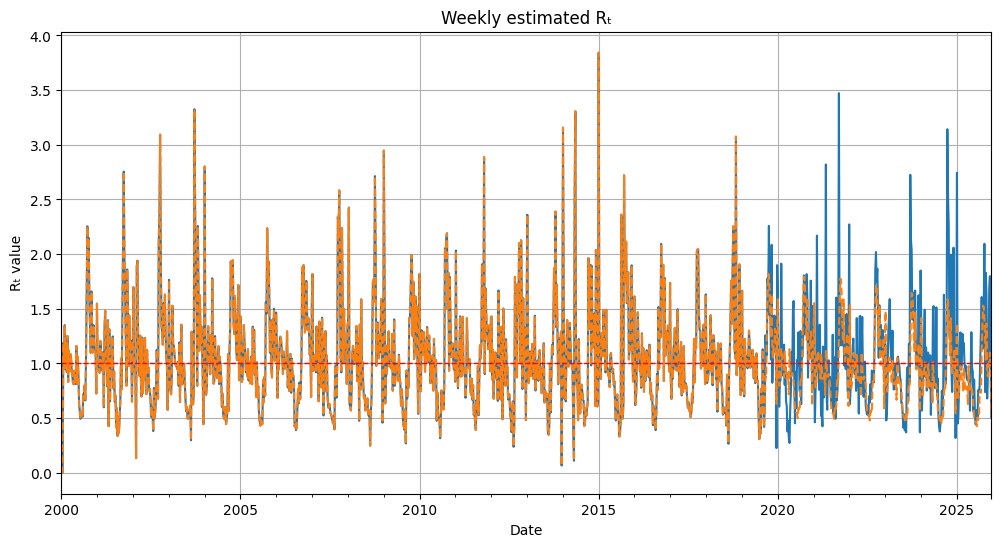

In [14]:
weekly_counterfactual_Rt = pd.Series(counterfactual_Rt, index=weekly_cases_filled.index)
weekly_St = pd.Series(S_scen0 / N, index=weekly_cases_filled.index)
weekly_remainders_mean_test = pd.Series(weekly_remainders_mean, index=weekly_cases_filled.index)

plt.figure(figsize=(12, 6))
weekly_Rt.plot()
weekly_counterfactual_Rt.plot(linestyle="--")
# weekly_remainders_mean_test.plot(linestyle="--")

plt.axhline(1.0, color='red', linestyle='--', linewidth=1)  # R=1 as reference
plt.title("Weekly estimated Rₜ")
plt.ylabel("Rₜ value")
plt.xlabel("Date")
plt.grid(True)

plt.show()

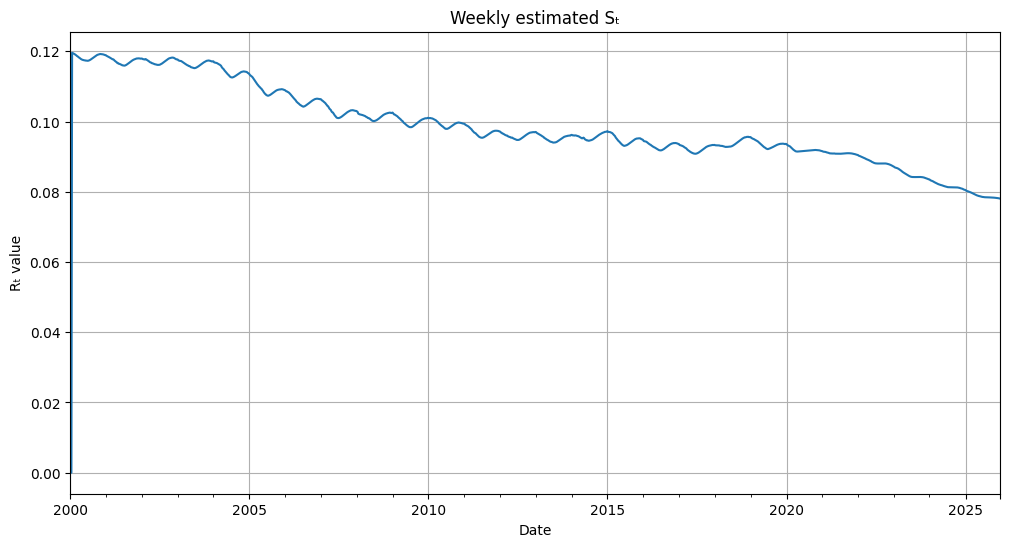

In [15]:
weekly_st_test = pd.Series(st_test, index=weekly_cases_filled.index)

plt.figure(figsize=(12, 6))
weekly_st_test.plot()

plt.title("Weekly estimated Sₜ")
plt.ylabel("Rₜ value")
plt.xlabel("Date")
plt.grid(True)

plt.show()

In [16]:
for t in range(max_tau, T-1):
    s_t = S_scen0[t] / N[t]
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    i_model[t] = R_t[t] * np.sum(i_model[t - np.arange(1, max_tau+1)] * kernel)

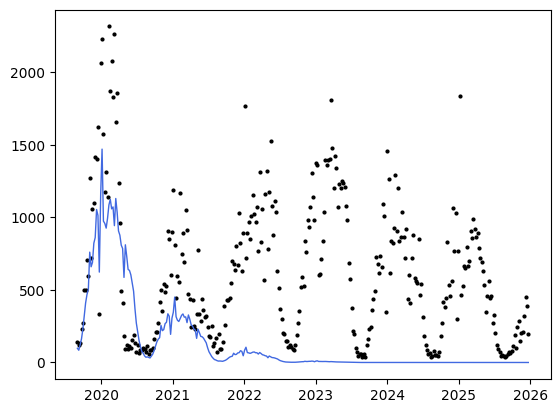

In [17]:
T = len(weekly_cases_filled)
i_cf = np.zeros(T)

# start: in the first max_tau weeks we use the observed data
i_cf[:max_tau] = weekly_cases_filled.iloc[:max_tau].values

for t in range(max_tau, T):
    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    past = i_cf[t - np.arange(1, max_tau+1)]
    denom = np.sum(past * kernel)
    s_t = S_scen0[t] / N[t]
    # i_cf[t] = s_t * counterfactual_Rt.iloc[t] * denom
    #i_cf[t] = counterfactual_Rt.iloc[t] * denom

    kernel = g * np.exp(-mu_t * np.arange(1, max_tau+1))
    i_cf[t] = counterfactual_Rt[t]  * np.sum(i_cf[t - np.arange(1, max_tau+1)] * kernel)

weekly_i_cf = pd.Series(i_cf, index=weekly_cases_filled.index)

mask_vaccination = (weekly_cases_filled.index >= start_of_vaccination) & (weekly_cases_filled.index < "2026-01-01")
plt.plot(weekly_i_cf.index[mask_vaccination], weekly_i_cf.values[mask_vaccination],
         label="Estimated number of cases", color="royalblue", linewidth=1)

plt.scatter(
    weekly_cases_filled.index[mask_vaccination],
    weekly_cases_filled.values[mask_vaccination],
    color="black",
    s=4,
    label="Observed data"
)
plt.show()

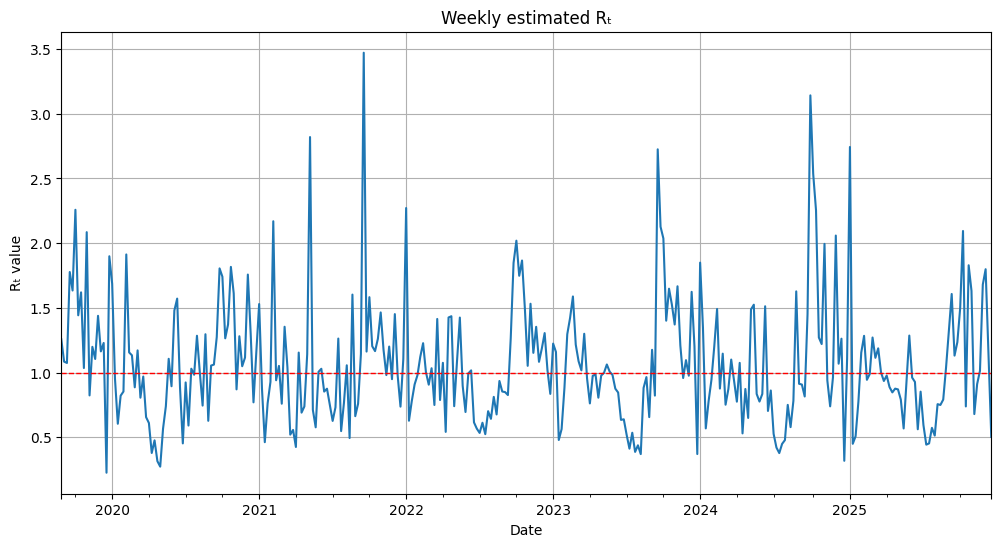

In [18]:
plt.figure(figsize=(12, 6))
weekly_Rt[mask_vaccination].plot()

plt.axhline(1.0, color='red', linestyle='--', linewidth=1)  # R=1 as reference
plt.title("Weekly estimated Rₜ")
plt.ylabel("Rₜ value")
plt.xlabel("Date")
plt.grid(True)

plt.show()